In [1]:
from scipy.optimize import minimize
from scipy.optimize import direct, Bounds
from smooth_POD_ROM.post_processing import richardson_lucy
from smooth_POD_ROM.pre_processing import smoothen_rowwise
from smooth_POD_ROM.initial_conditions import rectangular_pulse, rect_pulse_sin, saw_tooth, triangle, small_saw_tooth, small_r_pulse, very_small_r_pulse
from smooth_POD_ROM.reduced_order_model import optimize_hyperparameters, optimize_sROM, target_function, get_predictions, get_improvement
from smooth_POD_ROM.reduced_order_model import make_data_rw, train_ROM_rw, L2_error_rw, get_data_rw, train_ROM_rw, snapshots_rowwise
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 2.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
#mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 40

8.030570172000001


In [3]:
def small_saw_tooth(x, mu):
    return saw_tooth(x, mu, w=1/45)


def small_rectangular_pulse(x, mu):
    return rectangular_pulse(x, mu, w=0.01)

In [4]:
n_x = 5000
x = np.linspace(0, 1, n_x, endpoint=False)
case = {
    "n_x": n_x,
    "shape": x.shape,
    "x": x,
    "dx": x[1] - x[0],

    "n_train": 10,
    "n_test": 50,
    "g": small_rectangular_pulse, #saw_tooth, #rectangular_pulse, small_r_pulse, small_saw_tooth, very_small_r_pulse
    "truncate": 12,
    "sigma": 0.08,

    "c": 1.0,
    "monitor_progress_postprocessing": False,
    "num_iter": 200,
    "monitor_convergence": False,
}

# check snapshots, singular vectors and approximation.

(10, 5000) (10, 500) (500, 5000)


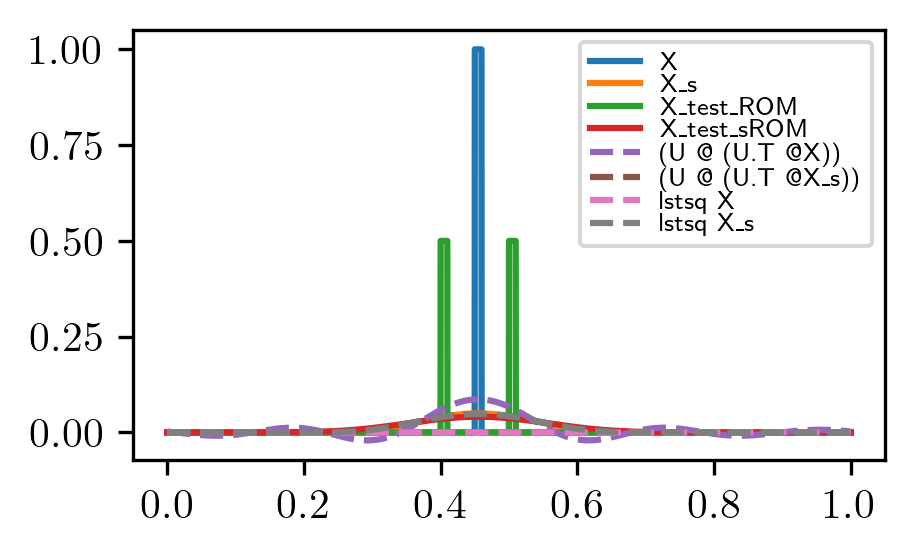

True
(10, 10) (10, 500)
(10, 1) (10,)
(500, 1) (500,)


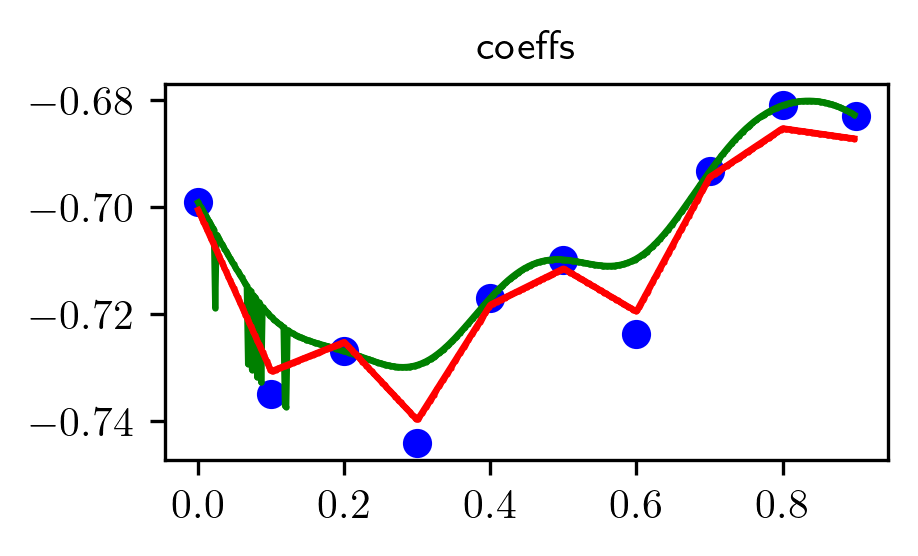

(10, 1) (10,)
(500, 1) (500,)


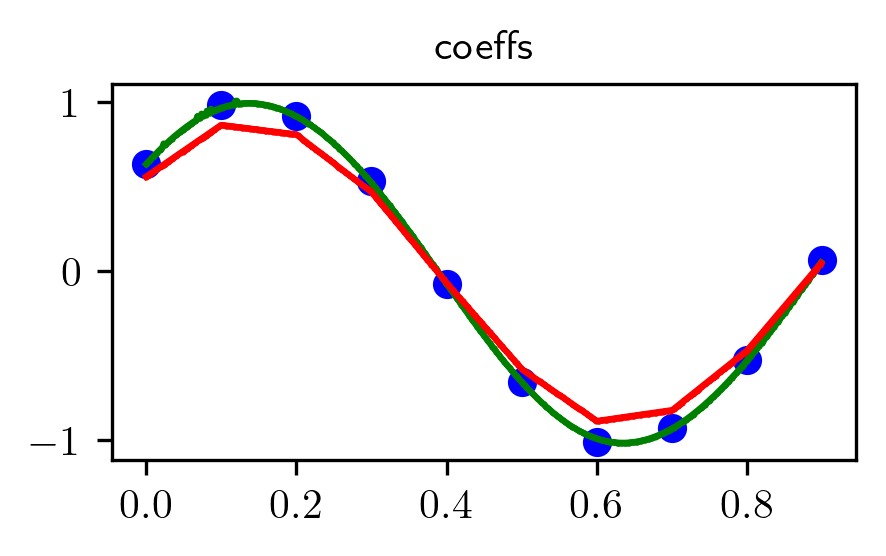

(10, 1) (10,)
(500, 1) (500,)


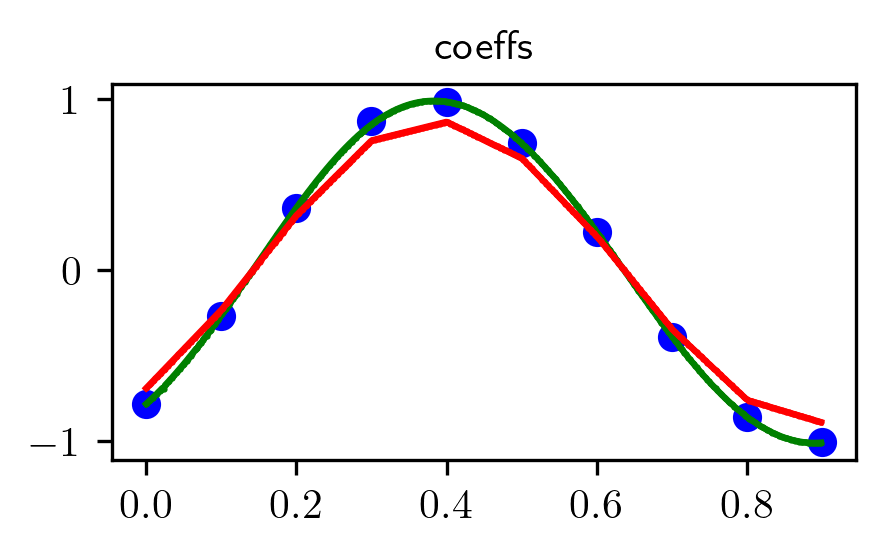

(10, 1) (10,)
(500, 1) (500,)


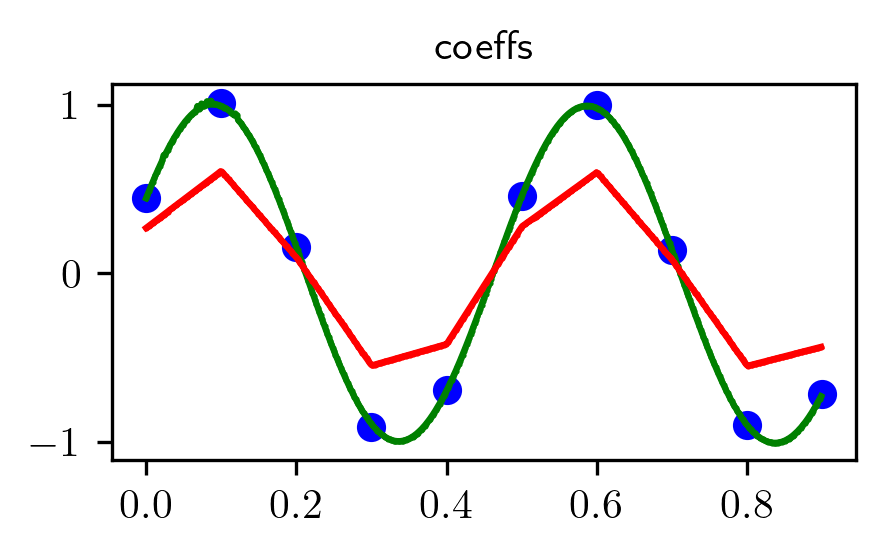

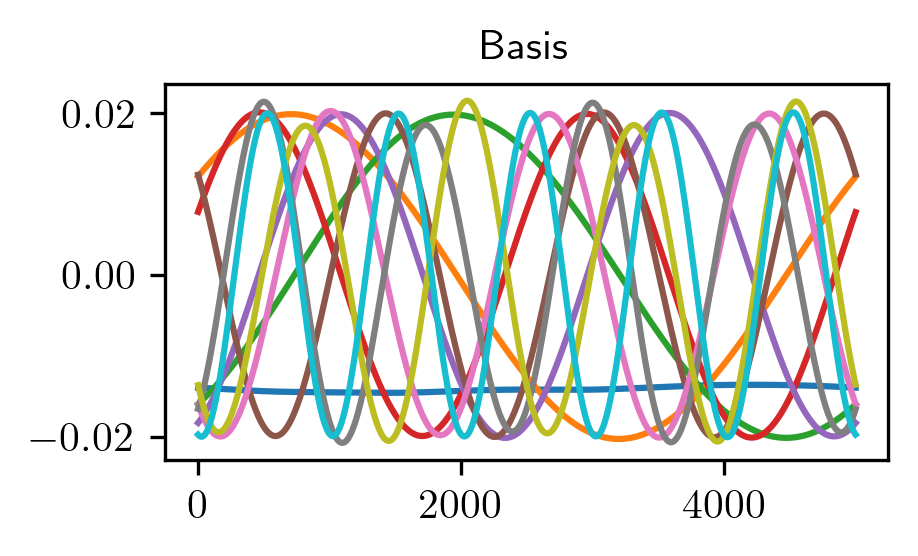

In [5]:
n_test = 500

mu_train = np.linspace([0], [1], case["n_train"], endpoint=False)

X_train, X_train_s = get_data_rw(mu_train, **case)

my_ROM = train_ROM_rw(mu_train, X_train)
my_sROM = train_ROM_rw(mu_train, X_train_s)

mu_test = np.linspace([0], [1-1/case["n_train"]], n_test, endpoint=False)
X_test, X_test_s = get_data_rw(mu_test, **case)

X_test_ROM = my_ROM.predict(mu_test).snapshots_matrix
X_test_sROM = my_sROM.predict(mu_test).snapshots_matrix
coeff_r = my_sROM.approximation.predict(mu_test).T

U_hat = my_ROM.reduction.modes
U_hat = my_sROM.reduction.modes
X_test_approx = (U_hat @ (U_hat.T @X_test.T)).T
X_test_approx_s = (U_hat @ (U_hat.T @X_test_s.T)).T

basis1 = X_train
basis2 = X_train_s
coefficients1, _, _, _ = np.linalg.lstsq(basis1.T, X_test.T, rcond=None)  # solves a@x=b given a and b
coefficients2, _, _, _ = np.linalg.lstsq(basis2.T, X_test_s.T, rcond=None)  # solves a@x=b given a and b
approximations1 = (basis1.T @ coefficients1).T  # same as X_test_ROM?
approximations2 = (basis2.T @ coefficients2).T  # same as X_test_sROM?
print(basis1.shape, coefficients1.shape, approximations1.shape)


for i in [250]: # [0, 500, 1000, 1500]:
    plt.plot(x, X_test[i, :], "C0", label="X")
    plt.plot(x, X_test_s[i, :], "C1", label="X_s")
    plt.plot(x, X_test_ROM[i, :], "C2", label="X_test_ROM")
    plt.plot(x, X_test_sROM[i, :], "C3", label="X_test_sROM")
    plt.plot(x, X_test_approx[i, :], "C4--", label="(U @ (U.T @X))")
    plt.plot(x, X_test_approx_s[i, :], "C5--", label="(U @ (U.T @X_s))")
    plt.plot(x, approximations1[i, :], "C6--", label="lstsq X")
    plt.plot(x, approximations2[i, :], "C7--", label="lstsq X_s")
plt.legend()
plt.show()
print(np.allclose(approximations2, X_test_approx_s))


coeff_train = U_hat.T @ X_train.T
coeff_test = U_hat.T @ X_test.T
print(coeff_train.shape, coeff_test.shape)
for i in range(4):
    print(mu_train.shape, coeff_train[i].shape)
    print(mu_test.shape, coeff_test[i].shape)
    plt.plot(mu_train[:, 0], coeff_train[i], "bo")
    plt.plot(mu_test[:, 0], coeff_test[i], "g.-", ms=1)
    plt.plot(mu_test[:, 0], coeff_r[i], "r.-", ms=1)
    plt.title("coeffs")
    plt.show()


# https://stats.stackexchange.com/a/211693

# X = snapshots_rowwise(rectangular_pulse, x, mu=np.linspace(0, 1, n_x, endpoint=False))
# X_s = smoothen_rowwise(X, 0.008, x.shape)
#X, X_s = get_data_rw(mu=np.linspace(0, 1, n_x, endpoint=False), sigma=case["sigma"], g=case["g"], x=case["x"])
# U, S, VT = np.linalg.svd(X_train_s.T, full_matrices=False)

# a, b = X.shape
# delta_n = (np.cumsum(S[::-1]**2)[::-1]/a/b)**.5
# dN = delta_n

# plt.imshow(X)
# plt.show()

for i in range(case["n_train"]):
    plt.plot(U_hat[:, i])
plt.title("Basis")
plt.show()



In [6]:
# case["mu_test"] = np.random.rand(case["n_test"])[:, None]#*0.1+.45
# del case["n_test"]
# case["mu_test"]

In [7]:
# rank = 20
# case["c"] = 1
# # case["num_iter"] = 250
# case["rank"] = rank
# case["n_train"] = rank
# # case["sROM_only"] = False
# case["sigma"] = 0.032

# mu_test  = case["mu_test"].copy()
# case["mu_test"] = mu_test.copy()
# in_range = mu_test[:, 0] < 1-1/rank
# case["mu_test"] = case["mu_test"][in_range, :]

# mu_train, X_train, X_train_s = make_data_rw([0], [1], n_samples=case["n_train"], **case)
# X_test, X_test_s = get_data_rw(case["mu_test"], **case)

# my_ROM = train_ROM_rw(mu_train, X_train)
# my_sROM = train_ROM_rw(mu_train, X_train_s)

# X_test_ROM = my_ROM.predict(case["mu_test"]).snapshots_matrix
# X_test_sROM, X_test_sROMs = get_predictions(my_sROM, case["mu_test"], **case)
# mean_ROM, mean_sROM, mean_sROMs, improvement = get_improvement(X_test, X_test_ROM, X_test_sROM, X_test_sROMs)

# case["mu_test"] = mu_test.copy()

# print("num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement")
# print(
#     "{:.0f}, {:.0f}, {:.0f}, {:.8f}, {:.8f}, {:.8f}, {:.8f}, {:.8f}, {:.4f}".format(
#         case["num_iter"],
#         len(mu_train),
#         len(mu_test),
#         case["sigma"],
#         case["c"],
#         mean_ROM,
#         mean_sROM,
#         mean_sROMs,
#         improvement,
#     )
# )

In [8]:
# # FIg 8
# markevery =80
# for i in range(10):
#     print(np.mean((X_test[i, :]-X_test_ROM[i, :])**2)**.5)
#     print(np.mean((X_test[i, :]-X_test_sROM[i, :])**2)**.5)
#     print(np.mean((X_test[i, :]-X_test_sROMs[i, :])**2)**.5)
#     fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
#     #plt.plot(x, X_intp_c_post, "r.")
#     #plt.plot(x, X_intp_c_post, "r.")
#     plt.plot(x, X_test[i, :], "kx--", ms=4, lw=1, markevery=(0, markevery), label="true solution")
#     plt.plot(x, X_test_ROM[i, :], "C0o-", ms=4, lw=1, markevery=(markevery//3, markevery), label="standard ROM")
#     plt.plot(x, X_test_sROM[i, :], "C1--", ms=4, lw=1, label="convolution + ROM")
#     plt.plot(x, X_test_sROMs[i, :], "C2|-", ms=4, lw=1, markevery=(markevery//3*2, markevery), label="convolution + ROM + post processing")
#     plt.legend()
#     plt.xlabel("x")
#     plt.ylabel("y")
#     #plt.title("{:.3f}, {:.3f}, {:.3f}".format(e1[i], e2[i], e3[i]))
#     ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
#     ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
#     plt.grid(True, which='minor', linestyle='--', lw=.25)
#     plt.grid(True, which='major', linestyle='-')
#     plt.xlim(case["mu_test"][i, 0]-0.1, case["mu_test"][i, 0]+0.1)
#     plt.show()

In [9]:
X = snapshots_rowwise(case["g"], x, mu=np.linspace(0, 1, n_x, endpoint=False))
U, S, VT = np.linalg.svd(X.T, full_matrices=False)
a, b = X.shape
delta_n = (np.cumsum(S[::-1]**2)[::-1]/a/b)**.5
dN = delta_n


# mu_test = np.random.rand(case["n_test"])[:, None]#*0.1+.45
# del case["n_test"]
# case["mu_test"]


n_test = case["n_test"]
del case["n_test"]

3
0.3333333333333333 0.6666666666666666


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 50, 0.06400000, 1.00000000, 0.12513360, 0.09890897, 0.10356995, -17.2325
0.3909720374736963 0.40939618223775787
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 50, 0.03200000, 1.00000000, 0.12513360, 0.10010105, 0.11014674, -11.9767
0.5595818783129645 0.6157389816975063
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 50, 0.01600000, 1.00000000, 0.12513360, 0.10271353, 0.12112800, -3.2011
0.8120217713251734 0.9576008848189008
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 50, 0.00800000, 1.00000000, 0.12513360, 0.10748996, 0.13061461, 4.3801
1.2017743106691308 1.4603157536102125
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 50, 0.00400000, 1.00000000, 0.12513360, 0.11425753, 0.1331

C:\Users\florianma\AppData\Local\Temp\10\ipykernel_382980\747607839.py:60: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "k." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(NN, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")


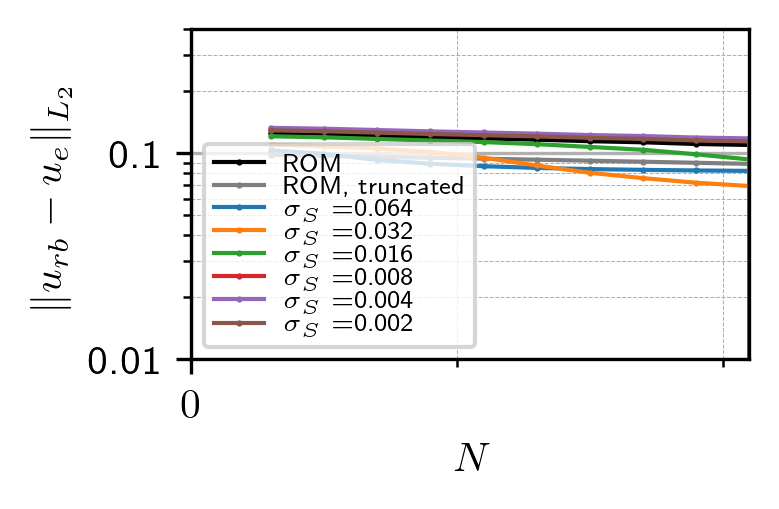

23
0.4782608695652174 0.5217391304347826


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 23, 50, 0.06400000, 1.00000000, 0.10766418, 0.09605013, 0.08194395, -23.8893
0.3796714834040824 0.3239119046230871
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 23, 50, 0.03200000, 1.00000000, 0.10766418, 0.09280125, 0.06719725, -37.5862
0.5187747664836149 0.37564407043591413
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 23, 50, 0.01600000, 1.00000000, 0.10766418, 0.08957413, 0.08552550, -20.5627
0.7081456615446882 0.6761384569185326
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 23, 50, 0.00800000, 1.00000000, 0.10766418, 0.09044933, 0.11276473, 4.7375
1.011254224205939 1.2607480222011949
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 23, 50, 0.00400000, 1.00000000, 0.10766418, 0.09556044, 0

C:\Users\florianma\AppData\Local\Temp\10\ipykernel_382980\747607839.py:60: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "k." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(NN, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")


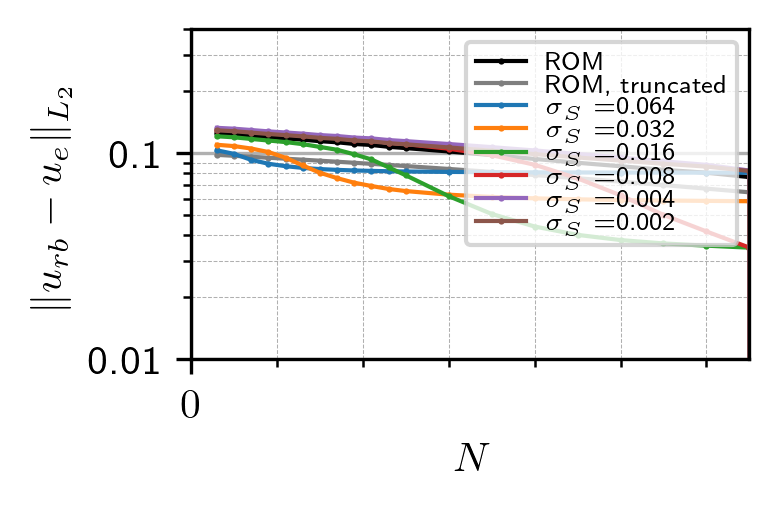

70
0.5 0.5142857142857142


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 70, 50, 0.06400000, 1.00000000, 0.07412738, 0.09591412, 0.08057687, 8.7005
0.3791338555055431 0.3185080333788252
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 70, 50, 0.03200000, 1.00000000, 0.07412738, 0.09181831, 0.05845892, -21.1372
0.5132799674379619 0.32679531397243267
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 70, 50, 0.01600000, 1.00000000, 0.07412738, 0.08417419, 0.03438068, -53.6195
0.6654553644541789 0.2718031070414224
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 70, 50, 0.00800000, 1.00000000, 0.07412738, 0.07331040, 0.03143640, -57.5914
0.8196351612059132 0.3514696467345652
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 70, 50, 0.00400000, 1.00000000, 0.07412738, 0.06627894, 

C:\Users\florianma\AppData\Local\Temp\10\ipykernel_382980\747607839.py:60: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "k." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(NN, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")


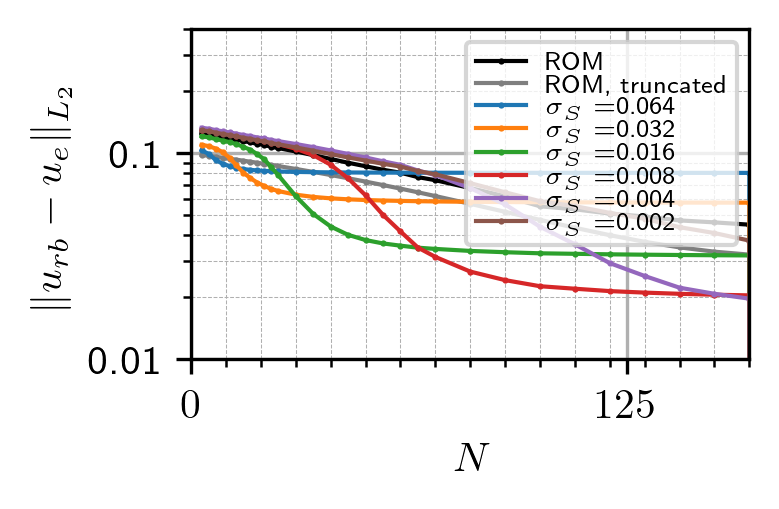

170
0.5 0.5058823529411764


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 170, 50, 0.06400000, 1.00000000, 0.04347628, 0.09589967, 0.08043521, 85.0094
0.37907671441623714 0.31794809818020475
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 170, 50, 0.03200000, 1.00000000, 0.04347628, 0.09170194, 0.05763816, 32.5738
0.5126294164966873 0.32220710147690285
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 170, 50, 0.01600000, 1.00000000, 0.04347628, 0.08329110, 0.03190400, -26.6174
0.6584739747287331 0.25222327401587985
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 170, 50, 0.00800000, 1.00000000, 0.04347628, 0.06813734, 0.02032529, -53.2497
0.7617986248305765 0.22724364904790367
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 170, 50, 0.00400000, 1.00000000, 0.04347628, 0.0

C:\Users\florianma\AppData\Local\Temp\10\ipykernel_382980\747607839.py:60: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "k." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(NN, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")


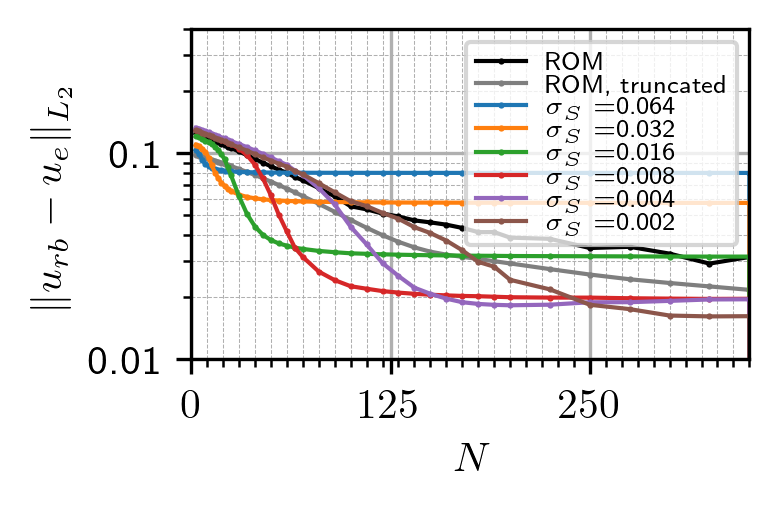

375
0.49866666666666665 0.5013333333333333


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 375, 50, 0.06400000, 1.00000000, 0.02715924, 0.09589719, 0.08041084, 196.0717
0.37906691657157665 0.31785175032745494
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 375, 50, 0.03200000, 1.00000000, 0.02715924, 0.09168173, 0.05749791, 111.7066
0.512516431334189 0.3214231084150355
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 375, 50, 0.01600000, 1.00000000, 0.02715924, 0.08313010, 0.03151982, 16.0556
0.6572011340889932 0.24918604699968666
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 375, 50, 0.00800000, 1.00000000, 0.02715924, 0.06704964, 0.01961332, -27.7840
0.7496377971264155 0.21928358238475842
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 375, 50, 0.00400000, 1.00000000, 0.02715924, 0.04

In [10]:
g = case["g"]
# mu_test = case["mu_test"].copy()
shape = case["shape"]
# num_iter1 = 100
# num_iter2 = 250
num_iter = 100
case["num_iter"] = num_iter
# case["c"] = 1

NN = np.array([*np.arange(3, 25, 2), *np.arange(25, 75, 5), *np.arange(80, 200, 10), *np.arange(200, 500, 25)])
#NN = np.array([3, *np.arange(10, 200, 20), *np.arange(200, 525, 25)])
#NN = np.array([500])  # np.array([100, 150, 250, 350, 500])
#NN = np.array([3, 50, 100, 250, 500])
#NN = np.array([*np.arange(10, 30, 2), 50, 100, 200, 300, 400, 500])
dN_ROM = np.zeros(len(NN))
dN_ROMi = np.zeros(len(NN))

sig = [0.0025, 0.01]
sig = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05]
sig = np.array([0.064, 0.032, 0.016, 0.008, 0.004, 0.002])
#sig = np.array([0.032, 0.008])
lbls = ["optimized", ".05/N**.5", ".01/N**.5", ".001/N**.5", "0.3/N", "0.2/N",  "0.1/N", "10/(N**2)", "25/(N**2)", "40/(N**2)"]

dN_sig_sROM = np.zeros((len(NN), len(sig)))
dN_sig_dsROM = np.zeros((len(NN), len(sig)))
for i, rank in enumerate(NN):
    n_train = rank
    print(rank)
    # case["num_iter"] = num_iter
    case["rank"] = rank
    case["n_train"] = n_train
    case["sROM_only"] = False

    s = rank//2
    case["mu_test"] = np.linspace(s/rank, (s+1)/rank, n_test, endpoint=False)[:, None]
    print(s/rank, (s+1)/rank)
    # case["mu_test"] = mu_test.copy()
    # in_range = mu_test[:, 0] < 1-1/rank
    # case["mu_test"] = case["mu_test"][in_range, :]
    
    basis = U[:, :rank]
    X_test, _ = get_data_rw(mu_test, **case)
    X_test_ROMi = (basis @ (basis.T @ X_test.T)).T
    e_ROMi = L2_error_rw(X_test_ROMi, X_test)
    mean_ROMi = np.mean(e_ROMi)
    dN_ROMi[i] = mean_ROMi


    for j in range(len(sig)):
        case["sigma"] = sig[j]
        mean_ROM, mean_sROM, mean_sROMs = target_function(case)
        dN_sig_sROM[i, j] = mean_sROM
        dN_sig_dsROM[i, j] = mean_sROMs
        print(mean_sROM/sig[j]**.5, mean_sROMs/sig[j]**.5)
        
    dN_ROM[i] = mean_ROM
    if (i+1) % 10 == 0:
        fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))

        plt.plot(NN, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")
        plt.plot(NN, dN_ROMi, "C7", ls="-", marker=".", lw=1, ms=1, label=r"ROM, truncated")
        for j in range(len(sig)):
            plt.plot(NN, dN_sig_dsROM[:, j], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+str(sig[j]))
        #plt.plot(NN, .4/NN**.5, "C2--", lw=1, ms=1, label=r"$0.4/\sqrt{N}$")
        plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
        plt.xlabel(r"$N$")
        plt.legend()
        ax.set_yscale("log")
        plt.xlim(0, rank)
        plt.ylim(0.02, 0.2)
        ax.set_xticks(np.linspace(0, 500, 51, endpoint=True), minor=True)
        ax.set_xticks([0, 125, 250, 375, 500], minor=False)
        ax.set_yticks([*np.linspace(0.01, 0.1, 10, endpoint=True), 0.2, 0.3, 0.4], minor=True)
        ax.set_yticks([0.1, 0.01], minor=False)
        #ax.set_yticklabels(["0.01"," ", "0.03"," ", "0.05", " ", "0.07", " ", " ", "0.1" ], minor=True)
        plt.grid(True, which="minor", linestyle="--", lw=0.25)
        plt.grid(True, which="major", linestyle="-")
        ax.set_yticklabels(["0.1", "0.01"], minor=False)
        plt.xlim(0, rank)
        
        plt.show()
pth = "../results/old"
#np.save(pth+"/dN.npy", dN)
np.save(pth+"/NN.npy", NN)
np.save(pth+"/dN_ROM.npy", dN_ROM)
np.save(pth+"/dN_ROMi.npy", dN_ROMi)
np.save(pth+"/dN_sig_sROM.npy", dN_sig_sROM)
np.save(pth+"/dN_sig_dsROM.npy", dN_sig_dsROM)

In [11]:
plateauS = dN_sig_sROM[i]
plateauDS = dN_sig_dsROM[i]
print(sig)
print(np.round(plateauS, decimals=3))
print(np.round(plateauDS, decimals=3))
print(np.round(plateauS/np.array(sig)**.5, decimals=3))
print(np.round(plateauDS/np.array(sig)**.5, decimals=3))

[0.064 0.032 0.016 0.008 0.004 0.002]
[0.096 0.092 0.083 0.067 0.046 0.032]
[0.08  0.057 0.032 0.02  0.02  0.018]
[0.379 0.513 0.657 0.749 0.721 0.717]
[0.318 0.321 0.249 0.219 0.319 0.396]


In [12]:
plateauS = dN_sig_sROM[i]
plateauDS = dN_sig_dsROM[i]
#  $\sS$        & 0.064 & 0.032 & 0.016 & 0.008 & 0.004 & 0.002\\
# plateau S-ROM  & 0.096 & 0.092 & 0.083 & 0.067 & 0.045 & 0.032\\
# plateau DS-ROM & 0.074 & 0.044 & 0.024 & 0.016 & 0.02  & 0.018\\
# C (S-ROM)      & 0.379 & 0.513 & 0.657 & 0.748 & 0.719 & 0.712\\
# C (DS-ROM)     & 0.293 & 0.246 & 0.191 & 0.184 & 0.321 & 0.409\\
print(r"$\sS$         ", *np.round(sig, decimals=3), sep=" & ", end="\\\\\n")
print(r"plateau S-ROM ", *np.round(plateauS, decimals=3), sep=" & ", end="\\\\\n")
print(r"plateau DS-ROM", *np.round(plateauDS, decimals=3), sep=" & ", end="\\\\\n")
print(r"C (S-ROM)     ", *np.round(plateauS/np.array(sig)**.5, decimals=3), sep=" & ", end="\\\\\n")
print(r"C (DS-ROM)    ", *np.round(plateauDS/np.array(sig)**.5, decimals=3), sep=" & ", end="\\\\\n")

$\sS$          & 0.064 & 0.032 & 0.016 & 0.008 & 0.004 & 0.002\\
plateau S-ROM  & 0.096 & 0.092 & 0.083 & 0.067 & 0.046 & 0.032\\
plateau DS-ROM & 0.08 & 0.057 & 0.032 & 0.02 & 0.02 & 0.018\\
C (S-ROM)      & 0.379 & 0.513 & 0.657 & 0.749 & 0.721 & 0.717\\
C (DS-ROM)     & 0.318 & 0.321 & 0.249 & 0.219 & 0.319 & 0.396\\


[0.064 0.032 0.016 0.008 0.004 0.002]

[0.08004655 0.07396857 0.06236488 0.04545092 0.03139018 0.02271016]

[0.06506673 0.04558852 0.03256524 0.0270865  0.0192637  0.01514171]

[0.31641175 0.41349686 0.4930377  0.50815671 0.49632234 0.50781458]

[0.25719882 0.2548476  0.25745082 0.30283626 0.30458579 0.33857894]

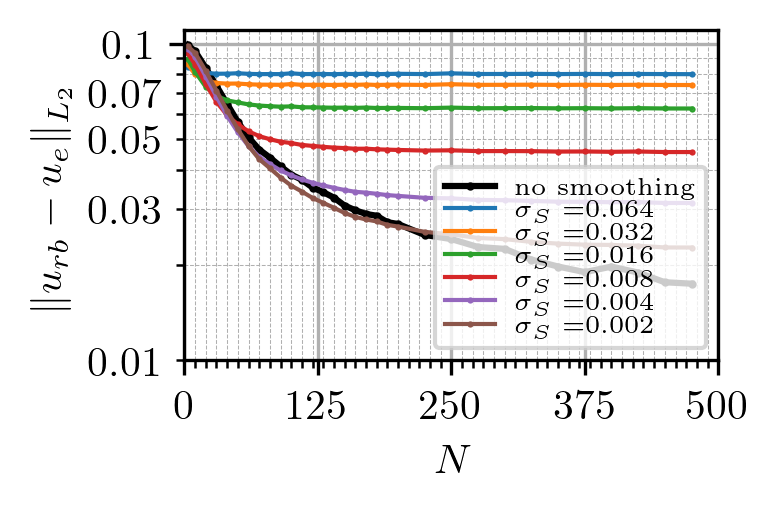

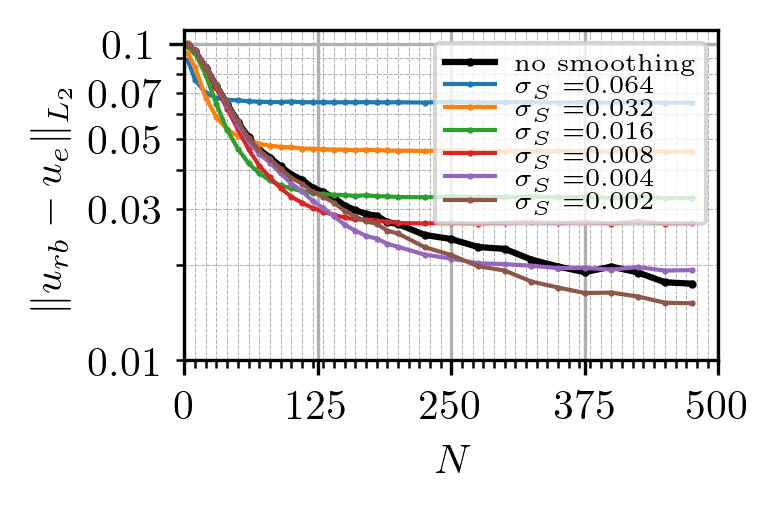

reduce to 1000 samples in x

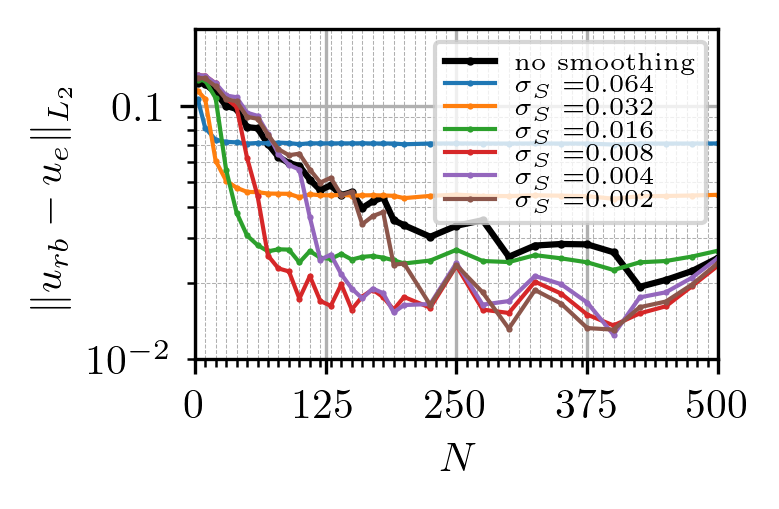

reduce to 10 test snapshots

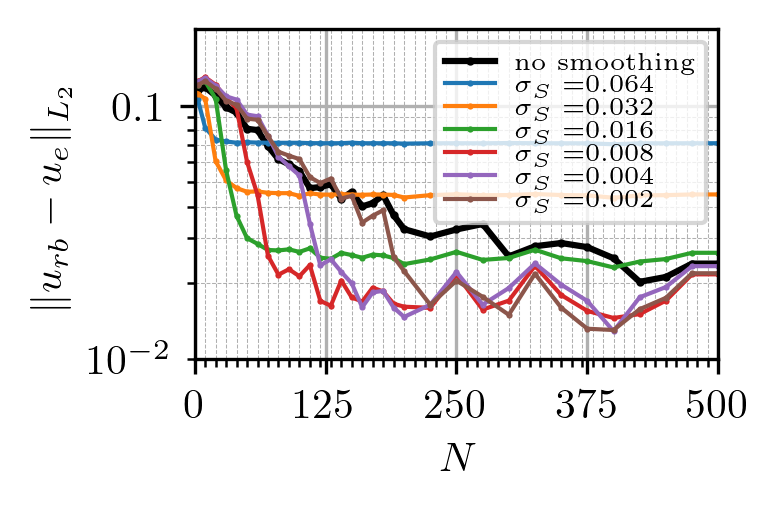

increase truncation of filter in deconvolution

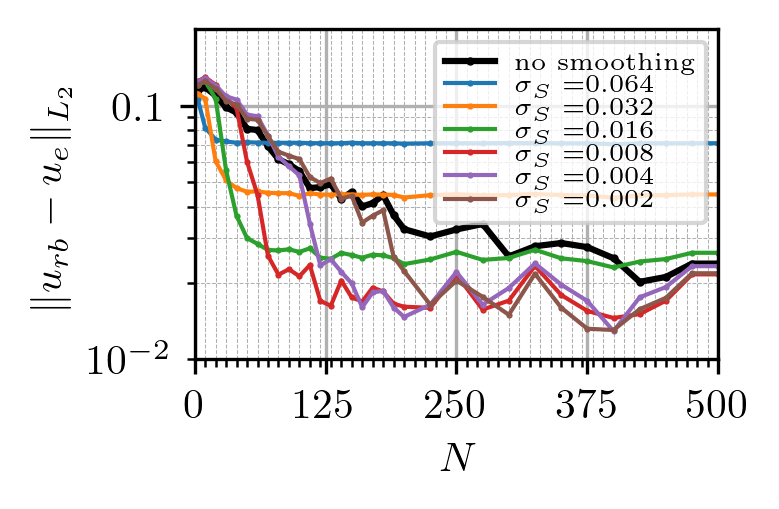

increase truncation in smoothing

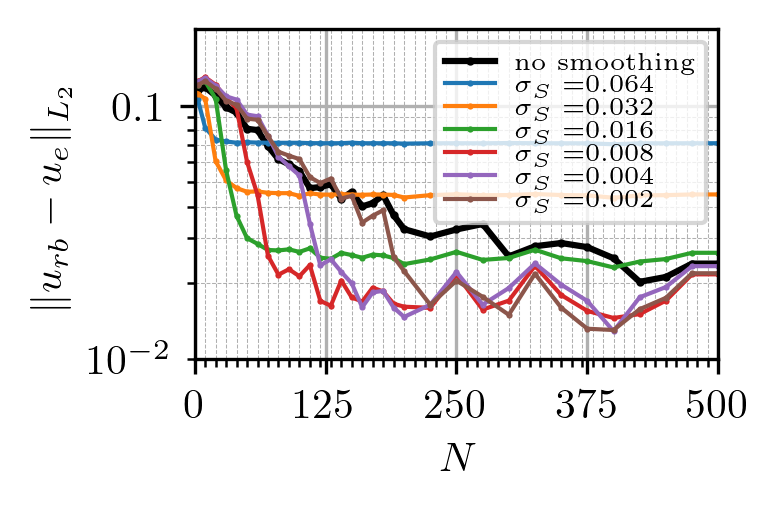

larger damping

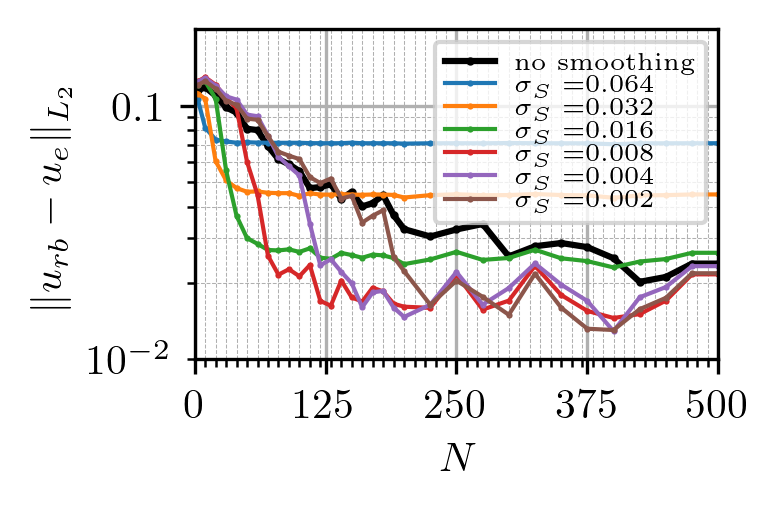

50 iterations, 5000 samples in x, damping = 1.2, truncate = 12

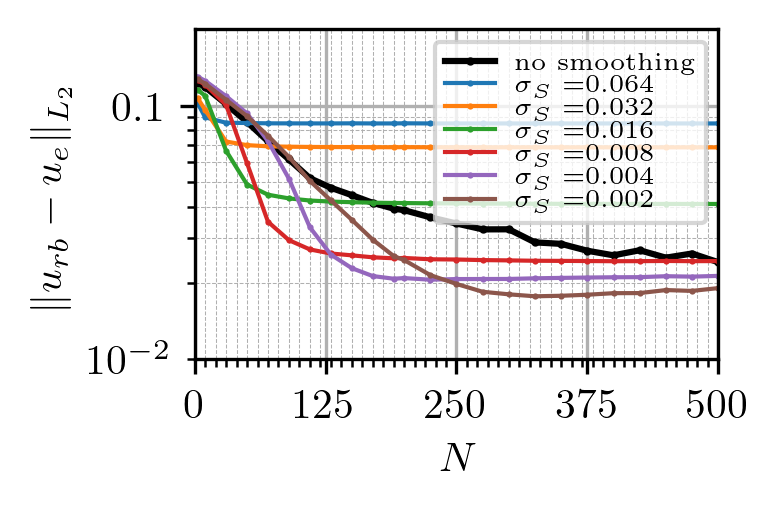


as sent to Kent (100 iterations, 5000 samples in x, damping = 2, truncate = 12, 25 test snapshots, pulse width=0.01)

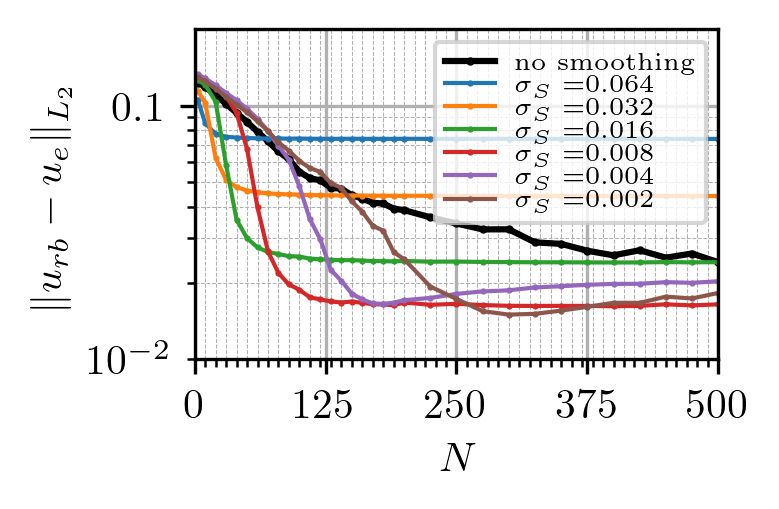

random snapshots:

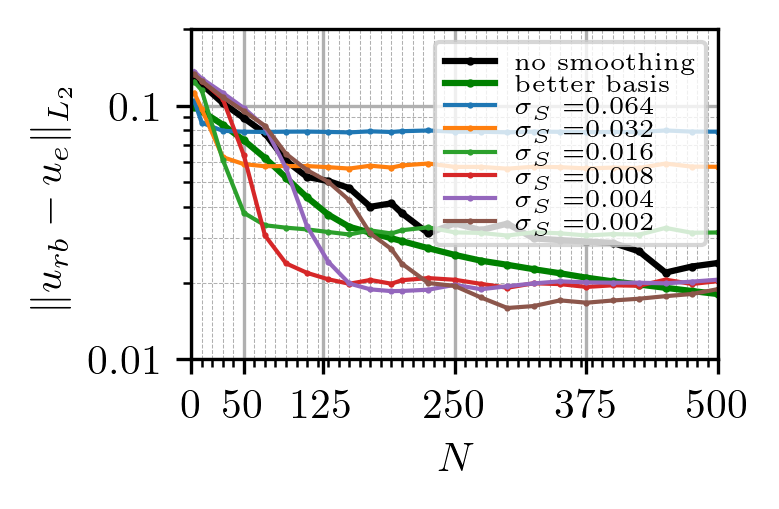


In [13]:


# dN = np.load(pth+"/dN.npy")
# NN = np.load(pth+"/NN2.npy")
# dN_ROM = np.load(pth+"/dN_ROM.npy")
# dN_ROMi = np.load(pth+"/dN_ROMi.npy")
# dN_sig_sROM = np.load(pth+"/dN_sig_sROM.npy")
# dN_sig_dsROM = np.load(pth+"/dN_sig_dsROM.npy")

# #sig = np.array([0.064, 0.032, 0.016, 0.008, 0.004, 0.002])

In [14]:
dN.shape, NN.shape, dN_ROM.shape, dN_ROMi.shape, dN_sig_sROM.shape
#sig = np.array([0.064, 0.032, 0.016, 0.008, 0.004, 0.002])

((5000,), (45,), (45,), (45,), (45, 6))

C:\Users\florianma\AppData\Local\Temp\10\ipykernel_382980\995121874.py:2: RuntimeWarning: divide by zero encountered in divide
  decay_estimate = .5/N**.5
C:\Users\florianma\AppData\Local\Temp\10\ipykernel_382980\995121874.py:6: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "k." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(NN, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")


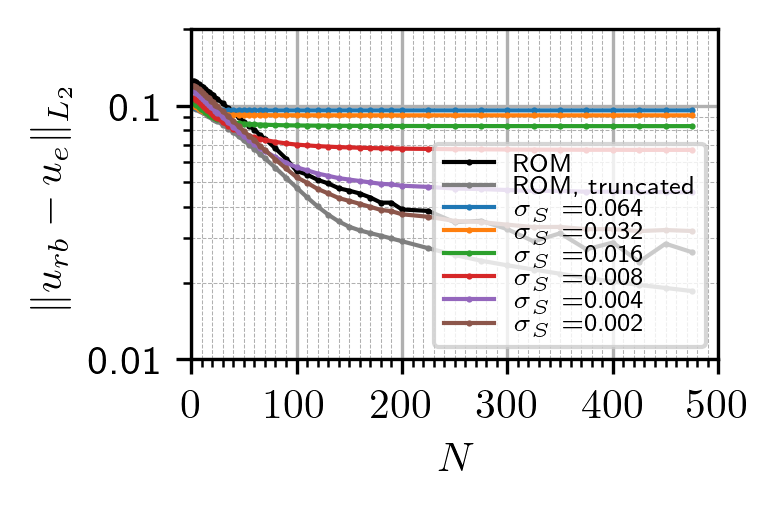

C:\Users\florianma\AppData\Local\Temp\10\ipykernel_382980\995121874.py:31: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "k." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(NN, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")


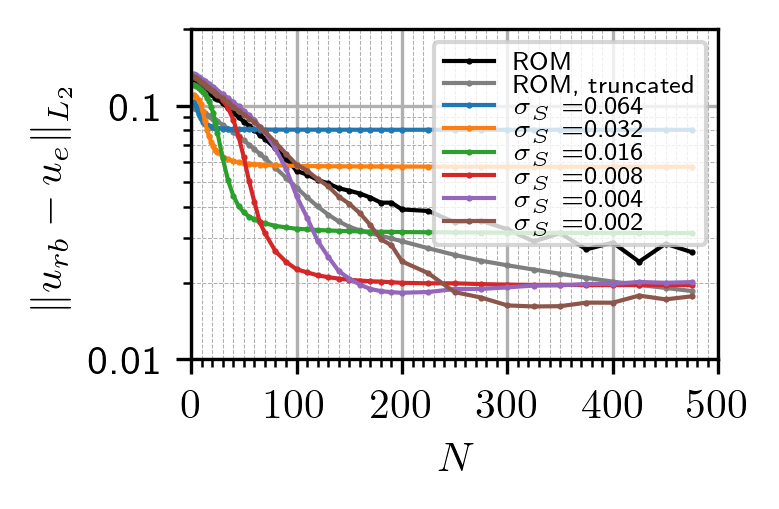

In [15]:
N = np.arange(len(dN))
decay_estimate = .5/N**.5


fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
plt.plot(NN, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")
plt.plot(NN, dN_ROMi, "C7", ls="-", marker=".", lw=1, ms=1, label=r"ROM, truncated")
#plt.plot(N, decay_estimate, "g.-", ms=2, label=r"decay estimate")
for j in range(len(sig)):
    plt.plot(NN, dN_sig_sROM[:, j], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+str(sig[j]))
#plt.plot(NN, .4/NN**.5, "C2--", lw=1, ms=1, label=r"$0.4/\sqrt{N}$")
plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
plt.xlabel(r"$N$")
plt.legend()
ax.set_yscale("log")
plt.xlim(0, 500)
plt.ylim(0.02, 0.2)
ax.set_xticks(np.linspace(0, 500, 51, endpoint=True), minor=True)
ax.set_xticks([0, 100, 200, 300, 400, 500], minor=False)
ax.set_yticks([*np.linspace(0.01, 0.1, 10, endpoint=True), 0.2, 0.3, 0.4], minor=True)
ax.set_yticks([0.1, 0.01], minor=False)
#ax.set_yticklabels(["0.01"," ", "0.03"," ", "0.05", " ", "0.07", " ", " ", "0.1" ], minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
ax.set_yticklabels(["0.1", "0.01"], minor=False)
plt.xlim(0, 500)
plt.ylim(0.01, 0.2)
plt.show()

fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
plt.plot(NN, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")
plt.plot(NN, dN_ROMi, "C7", ls="-", marker=".", lw=1, ms=1, label=r"ROM, truncated")
#plt.plot(N, decay_estimate, "g.-", ms=2, label=r"decay estimate")
for j in range(len(sig)):
    plt.plot(NN, dN_sig_dsROM[:, j], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+str(sig[j]))
#plt.plot(NN, .4/NN**.5, "C2--", lw=1, ms=1, label=r"$0.4/\sqrt{N}$")
plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
plt.xlabel(r"$N$")
plt.legend()
ax.set_yscale("log")
plt.xlim(0, 500)
plt.ylim(0.07, 0.2)
ax.set_xticks(np.linspace(0, 500, 51, endpoint=True), minor=True)
ax.set_xticks([0, 100, 200, 300, 400, 500], minor=False)
ax.set_yticks([*np.linspace(0.01, 0.1, 10, endpoint=True), 0.2, 0.3, 0.4], minor=True)
ax.set_yticks([0.1, 0.01], minor=False)
#ax.set_yticklabels(["0.01"," ", "0.03"," ", "0.05", " ", "0.07", " ", " ", "0.1" ], minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
ax.set_yticklabels(["0.1", "0.01"], minor=False)
plt.xlim(0, 500)
plt.ylim(0.01, 0.2)

plt.show()

In [16]:
g = case["g"]

shape = case["shape"]
num_iter1 = 100
num_iter2 = 250

#def estimate_dN():

# num_iter = 200
#NN = np.array([*np.arange(4, 30, 2), *np.arange(30, 150, 10)])
NN = np.array([*np.arange(3, 25, 2), *np.arange(25, 75, 5), *np.arange(80, 200, 10), *np.arange(200, 500, 25)])
dN_ROM = np.zeros(len(NN))
dN_sig = np.zeros((len(NN), 10))

sig = np.zeros((len(NN), 10))
sig[:, 1] = .05/NN**.5
sig[:, 2] = .01/NN**.5
sig[:, 3] = .001/NN**.5
#sig[:, 3] = .4 / (NN)
sig[:, 4] = .3 / (NN)
sig[:, 5] = .2 / (NN)   # this is the one for narrow saw tooth
sig[:, 6] = .1 / (NN)
sig[:, 7] = 10 / (NN**2)
sig[:, 8] = 25 / (NN**2)
sig[:, 9] = 40 / (NN**2)
lbls = ["optimized", ".05/N**.5", ".01/N**.5", ".001/N**.5", "0.3/N", "0.2/N",  "0.1/N", "10/(N**2)", "25/(N**2)", "40/(N**2)"]

for i, rank in enumerate(NN):
    n_train = rank
    print(rank)
    case["num_iter"] = num_iter1
    case["rank"] = rank
    case["n_train"] = n_train
    case["sROM_only"] = True
    
    # case["mu_test"] = mu_test.copy()
    # in_range = mu_test[:, 0] < 1-1/rank
    # case["mu_test"] = case["mu_test"][in_range, :]
    s = rank//2
    case["mu_test"] = np.linspace(s/rank, (s+1)/rank, n_test, endpoint=False)[:, None]
    
    parameters = optimize_sROM(case)
    sig[i, 0] = parameters[0]
    #sig[i, 0] = 0.02995521

    #for sigS, dN in zip([sig_opt, sig_1, sig_2, sig_3, sig_4], [dN_sig_opt, dN_sig_1, dN_sig_2, dN_sig_3, dN_sig_4]):
    for j in range(10):
        case["sigma"] = sig[i, j]
        mean_ROM, mean_sROM, mean_sROMs = target_function(case)
        dN_sig[i, j] = mean_sROM
        
    dN_ROM[i] = mean_ROM
np.save("./8_dN_ROM.npy", dN_ROM)
np.save("./8_dN_sig.npy", dN_sig)
np.save("./8_sig.npy", sig)
np.save("./8_NN.npy", NN)

3
max: 0.06666666666666667
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 50, 0.03333833, -, 0.12513360, 0.09999768, -, -20.0873
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 50, 0.05555722, -, 0.12513360, 0.09906580, -, -20.8320
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 50, 0.01111944, -, 0.12513360, 0.10491171, -, -16.1602
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 50, 0.06296352, -, 0.12513360, 0.09892504, -, -20.9445
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 50, 0.04815093, -, 0.12513360, 0.09926610, -, -20.6719
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 50, 0.04074463, -, 0.12513360, 0.09955714, -, -20.4393
num_iter, n_train, n_test, sigma_S, sigma_D

log log plot
plot sig S opt


In [17]:
# l = NN<70
# dN_sig[l, 5]

# from scipy.optimize import curve_fit

# def exp_func(x, a, b):
#     return a * np.exp(-b * x)  # No offset (simpler form)

# popt, pcov = curve_fit(exp_func, NN[l], dN_sig[l, 5], p0=(1/12, 300))  # Initial guess: (a=1, b=0.1)
# a_fit, b_fit = popt  # Extract fitted parameters
# print(popt)
# a_fit, b_fit = 1/12, 300
# plt.plot(NN[l], dN_sig[l, 5], "C0x")
# #plt.plot(NN, exp_func(NN, a_fit, b_fit))

[0.03 0.04 0.05 0.06 0.07 0.08 0.09]
[0.1]
[Text(0, 0.03, '0.03'), Text(0, 0.04, ' '), Text(0, 0.05, '0.05'), Text(0, 0.06, ' '), Text(0, 0.07, '0.07'), Text(0, 0.08, ' '), Text(0, 0.09, ' ')]


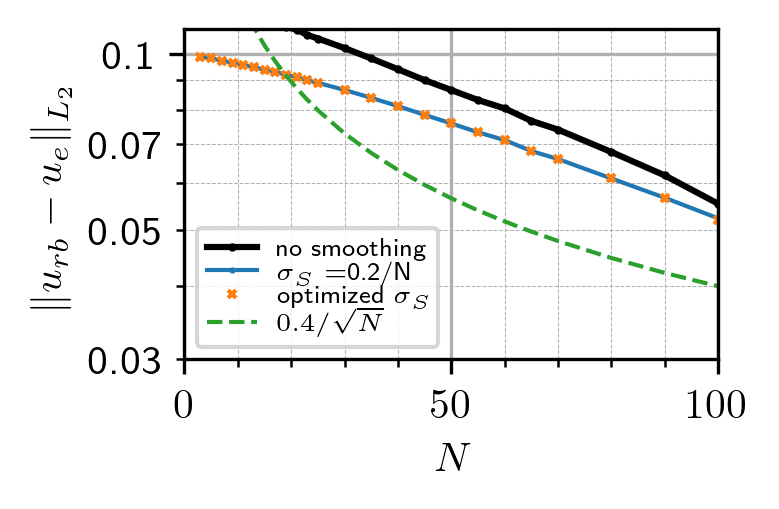

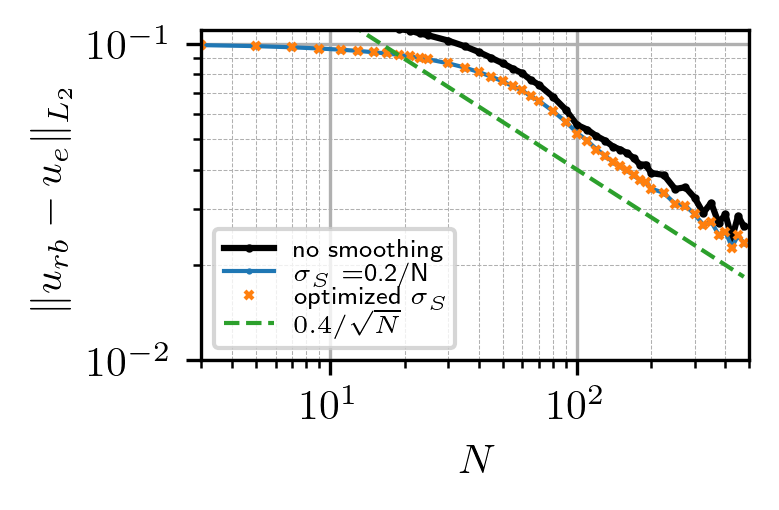

In [18]:
fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
#plt.plot(NN, esROM, "C1--", ms=2, label="$u_{rb,S}$")
plt.plot(NN, dN_ROM, "k.-", ms=2, label=r"no smoothing")
# for i in [2, 5, 7]: #range(4, 10):
#     plt.plot(NN, dN_sig[:, i], ls="-", marker=".", lw=1, ms=1, label=lbls[i])# r"$u_{\mu,Srb}$"
plt.plot(NN, dN_sig[:, 5], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+lbls[5])# r"$u_{\mu,Srb}$"
#plt.plot(NN, np.exp(-NN/300)/12, "C3--", lw=1, ms=1, label=r"$exp(-N)$")
plt.plot(NN, dN_sig[:, 0], ls="None", marker="x", lw=1, ms=2, label=r"optimized $\sigma_S$")# r"$u_{\mu,Srb}$"
plt.plot(NN, .4/NN**.5, "C2--", lw=1, ms=1, label=r"$0.4/\sqrt{N}$")

plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
plt.xlabel(r"$N$")
# plt.ylim(0, 0.4)
plt.legend()


ax.set_yscale("log")
plt.xlim(0, 100)
plt.ylim(0.03, 0.11)


ax.set_xticks(np.linspace(0, 100, 11, endpoint=True), minor=True)
ax.set_xticks([0, 50, 100], minor=False)

ax.set_yticks(np.linspace(0.03, 0.1, 8, endpoint=True), minor=True)
ax.set_yticks([0.1], minor=False)
ax.set_yticklabels(["0.03"," ", "0.05", " ", "0.07", " ", " ", "0.1" ], minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
# ax.set_yticks([0.03, 0.05, 0.06, 0.1], minor=False)
#ax.set_yticklabels(["0.03", "0.04", "0.06", "0.1"], minor=True)
ax.set_yticklabels(["0.1"], minor=False)




#ax.set_yticks(np.linspace(0.01, 0.1, 10, endpoint=True), minor=True)
#ax.set_yticklabels(["0.01", "0.1" ], minor=False)
#ax.set_yticklabels(["0.01", "0.02", "0.03"," 0.04", "0.05", "0.06", "0.07", "0.08", "0.09", "0.1" ], minor=True)
print(ax.get_yticks(minor=True))
print(ax.get_yticks(minor=False))
print(ax.get_yticklabels(minor=True))

# fmt = lambda x, pos: '{:.2f}'.format(x, pos)
# ax.yaxis.set_minor_formatter(mpl.ticker.FuncFormatter(fmt))
# ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(fmt))

plt.show()






fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
plt.plot(NN, dN_ROM, "k.-", ms=2, label="no smoothing")
# for i in [2, 5, 7]: #range(4, 10):
#     plt.plot(NN, dN_sig[:, i], ls="-", marker=".", lw=1, ms=1, label=lbls[i])# r"$u_{\mu,Srb}$"
plt.plot(NN, dN_sig[:, 5], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+lbls[5])# r"$u_{\mu,Srb}$"
plt.plot(NN, dN_sig[:, 0], ls="None", marker="x", lw=1, ms=2, label=r"optimized $\sigma_S$")# r"$u_{\mu,Srb}$"
plt.plot(NN, .4/NN**.5, "C2--", lw=1, ms=1, label=r"$0.4/\sqrt{N}$")# r"$u_{\mu,Srb}$"

plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
plt.xlabel(r"$N$")
# plt.ylim(0, 0.4)
plt.legend()
ax.set_xticks(np.linspace(0, 500, 51, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 0.4, 19, endpoint=True), minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
ax.set_xscale("log")
ax.set_yscale("log")
plt.xlim(3, 500)
plt.ylim(1e-2, 0.11)
plt.show()

Text(0, 0.5, '$\\sigma_S$')

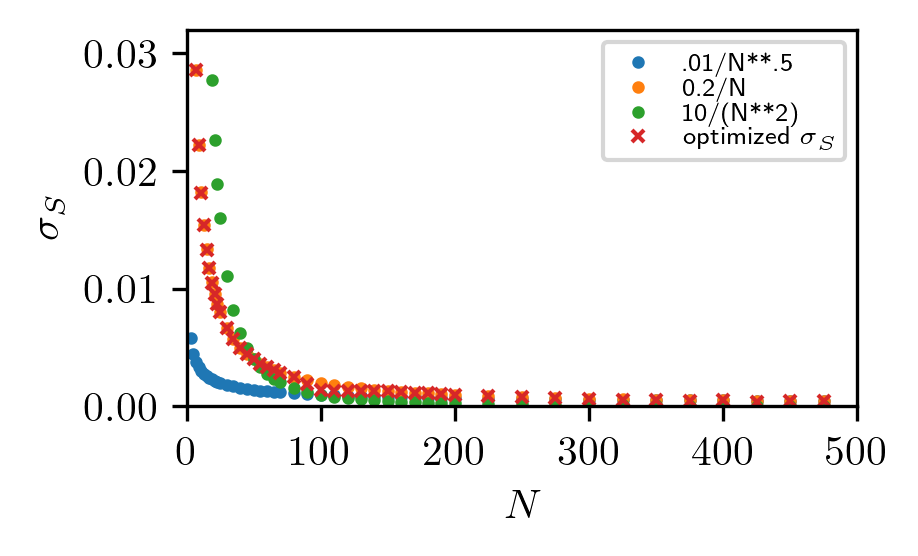

In [19]:
for i in [2, 5, 7]: #range(4, 10):
    plt.plot(NN, sig[:, i], "o", ms=2, label=lbls[i])
plt.plot(NN, sig[:, 0], "x", ms=3, label=r"optimized $\sigma_S$")
plt.legend()
plt.xlim(0, 500)
plt.ylim(0, 0.032)
plt.xlabel("$N$")
plt.ylabel(r"$\sigma_S$")